In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data generation (produksi listrik) dan weather (cuaca) untuk Plant 1
gen = pd.read_csv('../../dataset/dt_solar/Plant_1_Generation_Data.csv')
weather = pd.read_csv('../../dataset/dt_solar/Plant_1_Weather_Sensor_Data.csv')

print("Generation data:", gen.shape)
print("Weather data:", weather.shape)

gen.head()

Generation data: (68778, 7)
Weather data: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [3]:
# Cek tipe data DATE_TIME dulu di masing-masing tabel
print(gen['DATE_TIME'].head())
print(weather['DATE_TIME'].head())

0    15-05-2020 00:00
1    15-05-2020 00:00
2    15-05-2020 00:00
3    15-05-2020 00:00
4    15-05-2020 00:00
Name: DATE_TIME, dtype: str
0    2020-05-15 00:00:00
1    2020-05-15 00:15:00
2    2020-05-15 00:30:00
3    2020-05-15 00:45:00
4    2020-05-15 01:00:00
Name: DATE_TIME, dtype: str


In [4]:
# Ubah ke tipe datetime dengan format masing-masing
gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Gabungkan gen dan weather berdasarkan DATE_TIME
# (weather tidak per-inverter/SOURCE_KEY seperti gen, jadi digabung berdasarkan waktu saja)
df = pd.merge(gen, weather[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']], 
              on='DATE_TIME', how='left')

print(df.shape)
df.head()

(68778, 10)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64


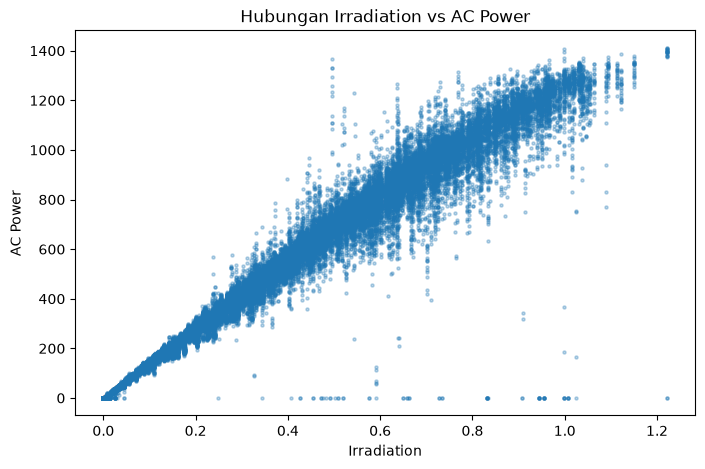

In [5]:
# Cek missing value
print(df.isnull().sum())

# Scatter plot: hubungan irradiation vs AC_POWER
plt.figure(figsize=(8,5))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, s=5)
plt.xlabel('Irradiation')
plt.ylabel('AC Power')
plt.title('Hubungan Irradiation vs AC Power')
plt.show()

In [6]:
# Buang baris dengan missing value
df = df.dropna(subset=['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'])
print("Setelah dropna:", df.shape)

# Lihat baris dengan irradiation tinggi tapi AC_POWER sangat rendah (kemungkinan inverter mati)
outlier_check = df[(df['IRRADIATION'] > 0.3) & (df['AC_POWER'] < 50)]
print("Jumlah baris outlier (kemungkinan inverter mati):", len(outlier_check))
outlier_check[['DATE_TIME', 'SOURCE_KEY', 'IRRADIATION', 'AC_POWER']].head(10)

Setelah dropna: (68774, 10)
Jumlah baris outlier (kemungkinan inverter mati): 62


,DATE_TIME,SOURCE_KEY,IRRADIATION,AC_POWER
815,2020-05-15 09:15:00,zVJPv84UY57bAof,0.344884,0.0
18490,2020-05-24 15:15:00,zBIq5rxdHJRwDNY,0.476600,0.0
20103,2020-05-25 10:15:00,ih0vzX44oOqAx2f,0.834157,0.0
46679,2020-06-07 12:15:00,bvBOhCH3iADSZry,1.024229,0.0
46690,2020-06-07 12:30:00,1BY6WEcLGh8j5v7,1.006504,0.0
46701,2020-06-07 12:30:00,bvBOhCH3iADSZry,1.006504,0.0
46708,2020-06-07 12:30:00,wCURE6d3bPkepu2,1.006504,0.0
46709,2020-06-07 12:30:00,z9Y9gH1T5YWrNuG,1.006504,0.0
46712,2020-06-07 12:45:00,1BY6WEcLGh8j5v7,0.998540,0.0
46723,2020-06-07 12:45:00,bvBOhCH3iADSZry,0.998540,0.0


In [7]:
# Buang baris outlier (inverter mati)
df = df[~((df['IRRADIATION'] > 0.3) & (df['AC_POWER'] < 50))]
print("Setelah buang outlier:", df.shape)

Setelah buang outlier: (68712, 10)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Tentukan fitur (X) dan target (y)
X = df[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y = df['AC_POWER']

# Bagi data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model selesai dilatih!")
print("Koefisien:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

Model selesai dilatih!
Koefisien: {'IRRADIATION': np.float64(1241.6353252308143), 'AMBIENT_TEMPERATURE': np.float64(-0.36685784847478), 'MODULE_TEMPERATURE': np.float64(1.5230809875769262)}
Intercept: -18.0165038008916


MAE  : 25.42
RMSE : 50.50
R²   : 0.9835


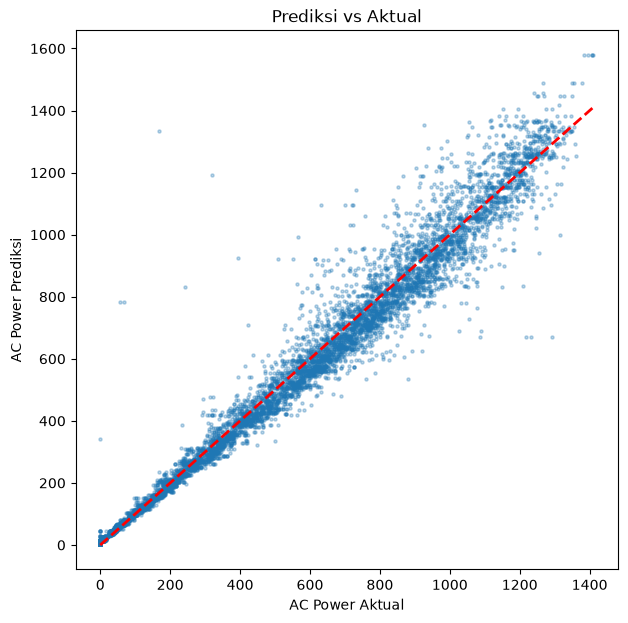

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prediksi pakai data testing
y_pred = model.predict(X_test)

# Hitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Visualisasi: prediksi vs aktual
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('AC Power Aktual')
plt.ylabel('AC Power Prediksi')
plt.title('Prediksi vs Aktual')
plt.show()

In [10]:
# Load data konsumsi listrik rumah tangga (UCI)
consumption = pd.read_csv('../../dataset/household_power_consumption.csv', sep=',', low_memory=False)

print(consumption.shape)
print(consumption.dtypes)
consumption.head()

(1048575, 9)
Date                         str
Time                         str
Global_active_power          str
Global_reactive_power        str
Voltage                      str
Global_intensity             str
Sub_metering_1               str
Sub_metering_2               str
Sub_metering_3           float64
dtype: object


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [11]:
# Cek berapa banyak nilai '?' di tiap kolom
print((consumption == '?').sum())

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3              0
dtype: int64


In [12]:
# Cek data duplikat di dataset solar (df)
print("Jumlah baris duplikat di data solar (df):", df.duplicated().sum())

# Cek data duplikat di dataset konsumsi
print("Jumlah baris duplikat di data konsumsi:", consumption.duplicated().sum())

Jumlah baris duplikat di data solar (df): 0
Jumlah baris duplikat di data konsumsi: 0


In [13]:
# Buang baris dengan nilai '?' di data konsumsi
consumption = consumption[consumption['Global_active_power'] != '?']
print("Setelah buang '?':", consumption.shape)

# Ubah kolom-kolom yang seharusnya angka dari teks ke tipe numerik
kolom_numerik = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                  'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for kol in kolom_numerik:
    consumption[kol] = consumption[kol].astype(float)

print(consumption.dtypes)

Setelah buang '?': (1044506, 9)
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
